In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

In [25]:
df = pd.read_csv('gemini.csv')
df_sample = df.sample(frac=1).reset_index(drop=True)
df_sample

,Пол,Кортизол,Глюкоза,Молочная к-та,Инсулин,МДА (Эритроциты),ФЛ(эр),СХ(эр),НЭЖК(эр),ТГ(эр),ЭХС(эр),МДА (Плазма),ФЛ(пл),СХ(пл),НЭЖК(пл),ТГ(пл),ЭХС(пл),З/П
0,0,0.10,0.97,0.56,0.89,0.07,0.06,0.67,0.48,0.67,0.77,0.35,0.12,0.48,0.83,0.42,0.34,0.0
1,0,0.78,0.16,0.08,0.42,0.29,0.31,0.47,0.79,0.40,0.65,0.33,0.16,1.00,0.72,0.33,0.00,0.0
2,0,0.46,0.55,0.53,0.07,0.07,0.54,0.32,0.50,0.33,0.24,0.89,0.36,0.29,0.00,0.71,0.62,1.0
3,1,0.28,0.23,1.00,0.91,0.14,0.03,0.53,1.00,0.53,0.59,0.27,0.76,0.21,0.33,0.43,0.12,1.0
4,1,0.09,0.99,0.52,0.88,0.07,0.04,0.68,0.53,0.66,0.77,0.35,0.09,0.51,0.85,0.43,0.29,0.0
5,0,0.70,0.55,0.53,0.72,0.86,0.13,0.68,0.64,0.47,0.53,0.90,0.20,0.36,0.50,0.48,0.56,1.0
6,0,0.51,0.07,0.53,0.30,0.07,0.08,0.74,0.50,0.53,0.71,0.54,0.16,0.43,0.06,0.81,0.56,1.0
7,0,0.10,1.02,0.54,0.89,0.07,0.07,0.70,0.51,0.68,0.78,0.35,0.12,0.51,0.83,0.43,0.32,0.0
8,0,0.54,0.14,0.53,0.44,0.07,0.10,0.47,0.71,1.00,0.35,0.57,0.04,0.43,0.78,0.29,0.69,1.0
9,1,0.29,0.14,0.53,0.43,0.14,0.23,0.58,0.50,0.53,0.41,0.30,0.68,0.36,0.44,0.19,0.38,0.0


In [26]:
y = df_sample['З/П']
X = df_sample.drop(['З/П'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [38]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth= 3)
model = classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
y_proba = classifier.predict_proba(X_test)[:, 1]

Accuracy:0.889
Precision:1.000
Recall:  0.833
F1-score: 0.909

Confusion Matrix:
 [[ 6  0]
 [ 2 10]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.75      1.00      0.86         6
         1.0       1.00      0.83      0.91        12

    accuracy                           0.89        18
   macro avg       0.88      0.92      0.88        18
weighted avg       0.92      0.89      0.89        18

F1-результаты по фолдам: [0.8        0.8        0.85714286 0.66666667 0.8       ]
Средний F1: 0.78


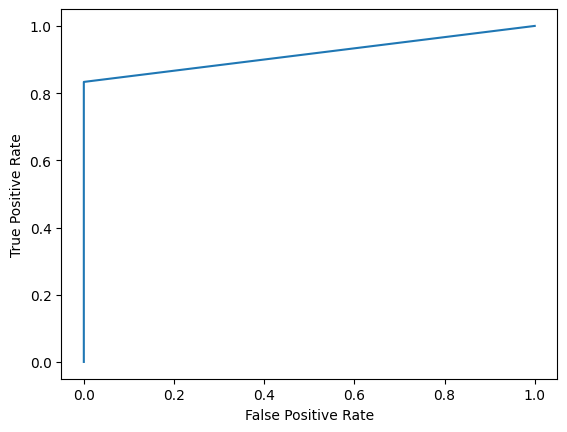

In [40]:
def metrix(prediction,clf, X_test):
    from sklearn.model_selection import cross_val_score
    accuracy_score(prediction, y_test)
    print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
    print(f"Precision:{precision_score(y_test, prediction):.3f}")
    print(f"Recall:  {recall_score(y_test, prediction):.3f}")
    print(f"F1-score: {f1_score(y_test, prediction):.3f}")
    # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
    print("\nClassification Report:\n", classification_report(y_test, prediction))


    scores_f1 = cross_val_score(clf, X_test, y_test, cv=5, scoring='f1')

    print(f"F1-результаты по фолдам: {scores_f1}")
    print(f"Средний F1: {scores_f1.mean():.2f}")
    from sklearn import metrics
    fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

    # построение ROC кривой
    plt.plot(fpr, tpr)
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return
metrix(y_pred, model, X_test)

In [29]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 88.89%


In [6]:
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:0.944
Precision:0.917
Recall:  1.000
F1-score: 0.957
ROC-AUC:1.000

Confusion Matrix:
 [[ 6  1]
 [ 0 11]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.86      0.92         7
         1.0       0.92      1.00      0.96        11

    accuracy                           0.94        18
   macro avg       0.96      0.93      0.94        18
weighted avg       0.95      0.94      0.94        18



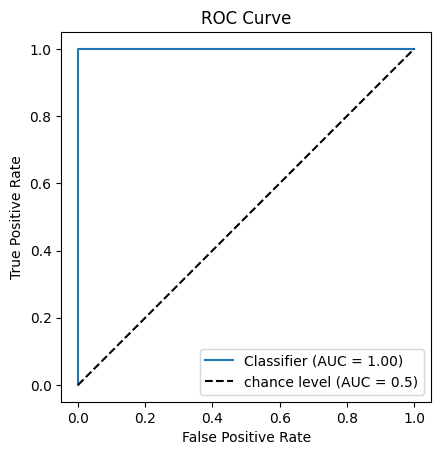

In [13]:
RocCurveDisplay.from_predictions(y_test, y_proba)

plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)") 
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

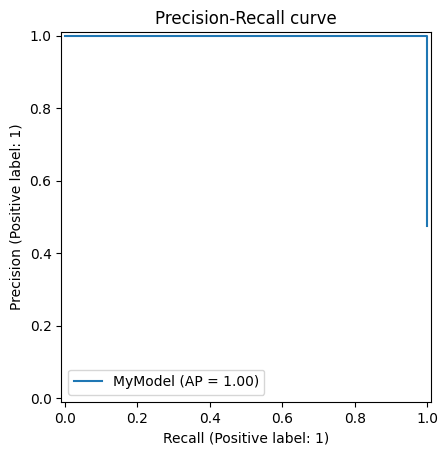

In [14]:
display = PrecisionRecallDisplay.from_predictions(y_test, y_proba, name="MyModel")

_ = display.ax_.set_title("Precision-Recall curve")
plt.show()

снизу оптимизаторы

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': range(1, 10, 1),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion': ["entropy", "gini"]
}

tree = DecisionTreeClassifier(random_state=1)

grid_search = GridSearchCV(estimator=tree, param_grid=param_grid,
                           cv=5, verbose=True)
grid_search.fit(X_train, y_train)

print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
best accuracy 0.9380952380952381
DecisionTreeClassifier(criterion='entropy', max_depth=2, min_samples_leaf=5,
                       random_state=1)


In [10]:
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical
from sklearn.tree import DecisionTreeClassifier

opt = BayesSearchCV(
    estimator=DecisionTreeClassifier(random_state=1),
    search_spaces={
        'max_depth': Integer(1, 20),
        'min_samples_leaf': Integer(1, 20),
        'min_samples_split': Integer(2, 20),
        'criterion': Categorical(["entropy", "gini"])
    },
    n_iter=32,
    cv=5,
    random_state=1,
    verbose=1
)

opt.fit(X_train, y_train)

print("best accuracy:", opt.best_score_)
print(opt.best_estimator_)

ModuleNotFoundError: No module named 'yaml'

In [11]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from scipy.stats import randint
from sklearn.tree import DecisionTreeClassifier

param_dist = {
    'max_depth': randint(1, 20),
    'min_samples_leaf': randint(1, 20),
    'min_samples_split': randint(2, 20),
    'criterion': ["gini", "entropy"]
}

halving = HalvingRandomSearchCV(
    estimator=DecisionTreeClassifier(random_state=1),
    param_distributions=param_dist,
    factor=2,
    random_state=1,
    verbose=1
)

halving.fit(X_train, y_train)

print("best accuracy:", halving.best_score_)
print(halving.best_estimator_)

n_iterations: 1
n_required_iterations: 1
n_possible_iterations: 1
min_resources_: 20
max_resources_: 34
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 1
n_resources: 20
Fitting 5 folds for each of 1 candidates, totalling 5 fits
best accuracy: 0.5833333333333333
DecisionTreeClassifier(criterion='entropy', max_depth=12, min_samples_leaf=13,
                       min_samples_split=10, random_state=1)


In [12]:
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    max_depth = trial.suggest_int("max_depth", 1, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        criterion=criterion,
        random_state=1
    )

    score = cross_val_score(model, X_train, y_train, cv=5).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print("Best params:", study.best_params)
print("Best score:", study.best_value)

c:\Users\e.i.chapaev\.conda\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-09 16:54:09,620] A new study created in memory with name: no-name-9e843ce9-117b-48da-a6d3-7b880f4a01b9
[I 2026-04-09 16:54:09,641] Trial 0 finished with value: 0.8857142857142858 and parameters: {'max_depth': 11, 'min_samples_leaf': 11, 'min_samples_split': 18, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8857142857142858.
[I 2026-04-09 16:54:09,660] Trial 1 finished with value: 0.819047619047619 and parameters: {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 18, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8857142857142858.
[I 2026-04-09 16:54:09,674] Trial 2 finished with value: 0.7047619047619047 and parameters: {'max_depth': 5, 'min_samples_leaf': 18, 'min_samples_split': 4, 'crite

Best params: {'max_depth': 18, 'min_samples_leaf': 5, 'min_samples_split': 3, 'criterion': 'entropy'}
Best score: 0.9380952380952381
